<a href="https://colab.research.google.com/github/KashishAgarwal0/BFS-DFS-PageRank_Parallel-DC/blob/main/Parallel_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://snap.stanford.edu/data/twitter_combined.txt.gz
!gunzip twitter_combined.txt.gz


--2025-04-30 12:48:55--  https://snap.stanford.edu/data/twitter_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10621918 (10M) [application/x-gzip]
Saving to: ‘twitter_combined.txt.gz’

twitter_combined.tx 100%[===================>]  10.13M  2.23MB/s    in 5.3s    

2025-04-30 12:49:01 (1.91 MB/s) - ‘twitter_combined.txt.gz’ saved [10621918/10621918]



In [ ]:
!head -n 1000000 twitter_combined.txt > twitter_small.txt

In [ ]:
import numpy as np

file_path = "twitter_combined.txt"

# Step 1: Build ID mapping (original ID → compact ID)
unique_ids = set()
with open(file_path, 'r') as f:
    for line in f:
        if line.strip() == "":
            continue
        u, v = map(int, line.strip().split())
        unique_ids.add(u)
        unique_ids.add(v)

sorted_ids = sorted(list(unique_ids))
id_map = {orig_id: new_id for new_id, orig_id in enumerate(sorted_ids)}
num_nodes = len(id_map)

print(f"Total unique users = {num_nodes}")

# Step 2: Count degrees
degree = np.zeros(num_nodes, dtype=np.int32)
with open(file_path, 'r') as f:
    for line in f:
        if line.strip() == "":
            continue
        u, v = map(int, line.strip().split())
        degree[id_map[u]] += 1

# Step 3: Build row_ptr
row_ptr = np.zeros(num_nodes + 1, dtype=np.int32)
row_ptr[1:] = np.cumsum(degree)

# Step 4: Fill col_ind
col_ind = np.zeros(row_ptr[-1], dtype=np.int32)
current_pos = row_ptr[:-1].copy()

with open(file_path, 'r') as f:
    for line in f:
        if line.strip() == "":
            continue
        u, v = map(int, line.strip().split())
        u_new = id_map[u]
        v_new = id_map[v]
        col_ind[current_pos[u_new]] = v_new
        current_pos[u_new] += 1

# Step 5: Save the clean files
np.save("row_ptr.npy", row_ptr)
np.save("col_ind.npy", col_ind)

print("CSR conversion complete! 🎉")


Total unique users = 81306
CSR conversion complete! 🎉


In [ ]:
import numpy as np
row_ptr = np.load("row_ptr.npy")
col_ind = np.load("col_ind.npy")


In [ ]:
import os

project_dir = "Parallel_Project_WonderWorvicks"
os.makedirs(project_dir, exist_ok=True)
os.makedirs(f"{project_dir}/utils", exist_ok=True)


In [ ]:
import shutil

shutil.move("row_ptr.npy", f"{project_dir}/row_ptr.npy")
shutil.move("col_ind.npy", f"{project_dir}/col_ind.npy")


'Parallel_Project_WonderWorvicks/col_ind.npy'

In [ ]:
readme_text = """# CUDA-Optimized Graph Algorithms

## 📁 Data Format (CSR):
- Graph is stored in Compressed Sparse Row (CSR) format using two files:
  - row_ptr.npy — Row pointer array
  - col_ind.npy — Column index array

## 💻 How to Load the Graph in Python:
  import numpy as np
  row_ptr = np.load("row_ptr.npy")
  col_ind = np.load("col_ind.npy")

## 👥 Team Task Breakdown:
- bfs_gpu.cu → BFS implementation on GPU (Person 1)
- dfs_gpu.cu → DFS on GPU (Person 2)
- pagerank_gpu.cu → PageRank using power iteration (Person 3)

Each file should load the graph using CSR format and implement its algorithm on the GPU.

➡️ All outputs should print execution time (vs CPU if possible) and be wrapped in a main() so we can compile/run easily.
"""

with open("Parallel_Project_WonderWorvicks/README.txt", "w") as f:
    f.write(readme_text)

print("README.txt created successfully ✅")


README.txt created successfully ✅


In [ ]:


for filename in ["bfs_gpu.cu", "dfs_gpu.cu", "pagerank_gpu.cu"]:
    with open(f"{project_dir}/{filename}", "w") as f:
        f.write("// Start your CUDA code here\n")


In [ ]:
!zip -r Parallel_Project_WonderWorvicks.zip Parallel_Project_WonderWorvicks/

  adding: Parallel_Project_WonderWorvicks/ (stored 0%)
  adding: Parallel_Project_WonderWorvicks/dfs_gpu.cu (stored 0%)
  adding: Parallel_Project_WonderWorvicks/README.txt (deflated 39%)
  adding: Parallel_Project_WonderWorvicks/bfs_gpu.cu (stored 0%)
  adding: Parallel_Project_WonderWorvicks/pagerank_gpu.cu (stored 0%)
  adding: Parallel_Project_WonderWorvicks/col_ind.npy (deflated 43%)
  adding: Parallel_Project_WonderWorvicks/utils/ (stored 0%)
  adding: Parallel_Project_WonderWorvicks/row_ptr.npy (deflated 64%)


In [ ]:
# Create a new Python file inside your project folder
with open("Parallel_Project_WonderWorvicks/pagerank_cpu.py", "w") as f:
    f.write("# CPU PageRank code will go here\n")


In [ ]:
!python3 Parallel_Project_WonderWorvicks/pagerank_cpu.py


Running PageRank CPU for 20 iterations...
CPU PageRank finished in 55.3251 seconds 🚀
First 10 node ranks: [3.94472457e-04 3.29272852e-04 7.47503887e-06 4.46613986e-06
 4.60890934e-04 1.78031234e-05 6.99784848e-06 7.36092229e-06
 1.99533835e-06 2.08774711e-05]


In [ ]:
!nvcc -o pagerank_gpu Parallel_Project_WonderWorvicks/pagerank_gpu.cu
!./pagerank_gpu

Parallel_Project_WonderWorvicks/pagerank_gpu.cu(36): warning #550-D: variable "num_edges" was set but never used
      int num_nodes, num_edges;
                     ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

First 10 node ranks:
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
GPU PageRank finished in 9.6697 ms


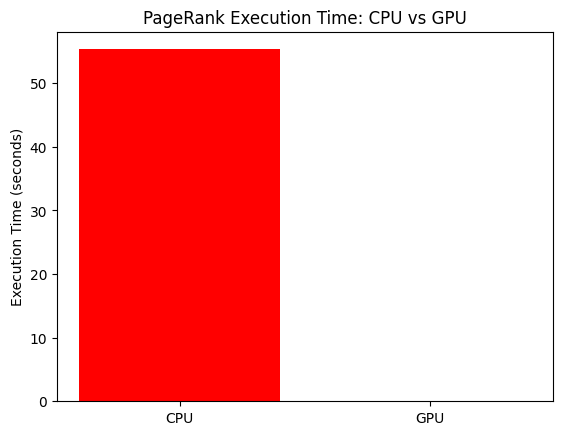

In [ ]:
import matplotlib.pyplot as plt

times = [55.3251, 0.0096677]
labels = ['CPU', 'GPU']

plt.bar(labels, times, color=['red', 'green'])
plt.ylabel('Execution Time (seconds)')
plt.title('PageRank Execution Time: CPU vs GPU')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
